<a href="https://colab.research.google.com/github/Bushra-engr/Cat_vs_Dog_Image_Classification/blob/main/Cat_vs_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extract_dir = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
  print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'")
except zipfile.BadZipFile:
  print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except FileNotFoundError:
  print(f"Error: The zip file '{zip_file_path}' was not found.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Successfully unzipped '/content/archive (1).zip' to '/content/'


In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Dropout,Conv2D,BatchNormalization,MaxPooling2D,Flatten
from keras.models import Sequential

In [5]:
#generators

train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)

)
test_ds=keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [3]:
# Normalize

def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

In [6]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
train_ds=train_ds.map(process)

In [8]:
test_ds=test_ds.map(process)

# CNN Model

In [26]:
model=Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(filters=64,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(filters=128,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
history=model.fit(
    train_ds,
    epochs=10,
    verbose=1,
    validation_data=test_ds
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 95ms/step - accuracy: 0.6115 - loss: 1.2670 - val_accuracy: 0.6986 - val_loss: 0.5930
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.7138 - loss: 0.5622 - val_accuracy: 0.7244 - val_loss: 0.5578
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.7757 - loss: 0.4703 - val_accuracy: 0.7026 - val_loss: 0.5769
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8095 - loss: 0.4172 - val_accuracy: 0.7630 - val_loss: 0.5043
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8474 - loss: 0.3490 - val_accuracy: 0.7708 - val_loss: 0.5758
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.8795 - loss: 0.2846 - val_accuracy: 0.7754 - val_loss: 0.5663
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9147 - loss: 0.2095 - val_accuracy: 0.8184 - val_loss: 0.6487
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.9510 - loss: 0.1269 -

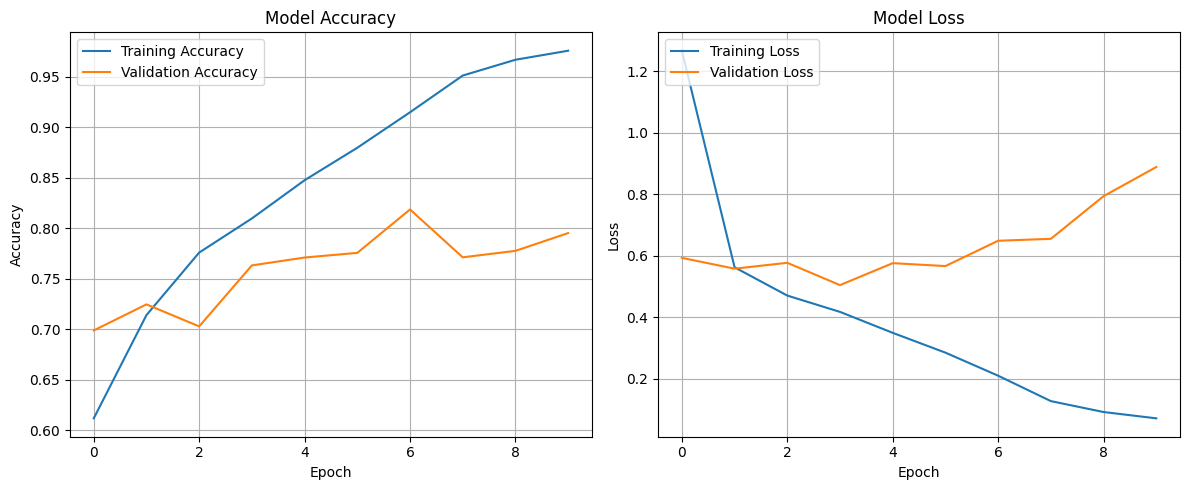

In [32]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )
plt.tight_layout()
plt.show()

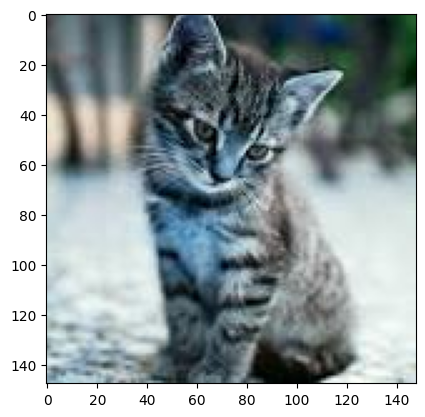

In [81]:
import cv2
cat_img=cv2.imread('/content/cat.jpg')
plt.imshow(cat_img)

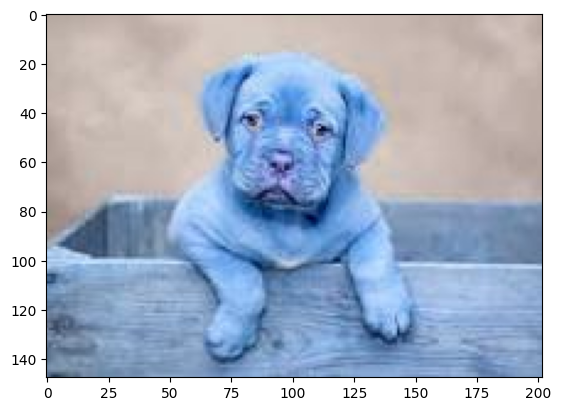

In [76]:
dog_img=cv2.imread('/content/dog.jpg')
plt.imshow(dog_img)

In [77]:
print(cat_img.shape)
print(dog_img.shape)

(148, 253, 3)
(148, 202, 3)


In [82]:
cat_img=cv2.resize(cat_img,(256,256))
dog_img=cv2.resize(dog_img,(256,256))

cat_input=cat_img.reshape((1,256,256,3))
dog_input=dog_img.reshape((1,256,256,3))

In [83]:
model.predict(cat_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.]], dtype=float32)

In [84]:
model.predict(dog_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.99999523]], dtype=float32)

In [54]:
# Create a data augmentation layer
data_augmentation = keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

# Apply data augmentation to the training dataset
# Using .map() is suitable for applying this layer on-the-fly during training
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

print("Data augmentation pipeline created and applied to training dataset.")

Data augmentation pipeline created and applied to training dataset.


In [55]:
history2=model.fit(
    augmented_train_ds, # <--- Change this line
    epochs=10,
    verbose=1,
    validation_data=test_ds
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 524ms/step - accuracy: 0.8202 - loss: 0.4107 - val_accuracy: 0.8182 - val_loss: 0.3994
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.8504 - loss: 0.3487 - val_accuracy: 0.8118 - val_loss: 0.4243
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 514ms/step - accuracy: 0.8641 - loss: 0.3239 - val_accuracy: 0.8062 - val_loss: 0.4241
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 325s 519ms/step - accuracy: 0.8698 - loss: 0.3045 - val_accuracy: 0.8526 - val_loss: 0.3409
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.8788 - loss: 0.2892 - val_accuracy: 0.8622 - val_loss: 0.3248
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 517ms/step - accuracy: 0.8895 - loss: 0.2700 - val_accuracy: 0.8872 - val_loss: 0.2776
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 326s 522ms/step - accuracy: 0.8956 - loss: 0.2533 - val_accuracy: 0.8596 - val_loss: 0.3339
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 518ms/step - accuracy: 0.9018 -

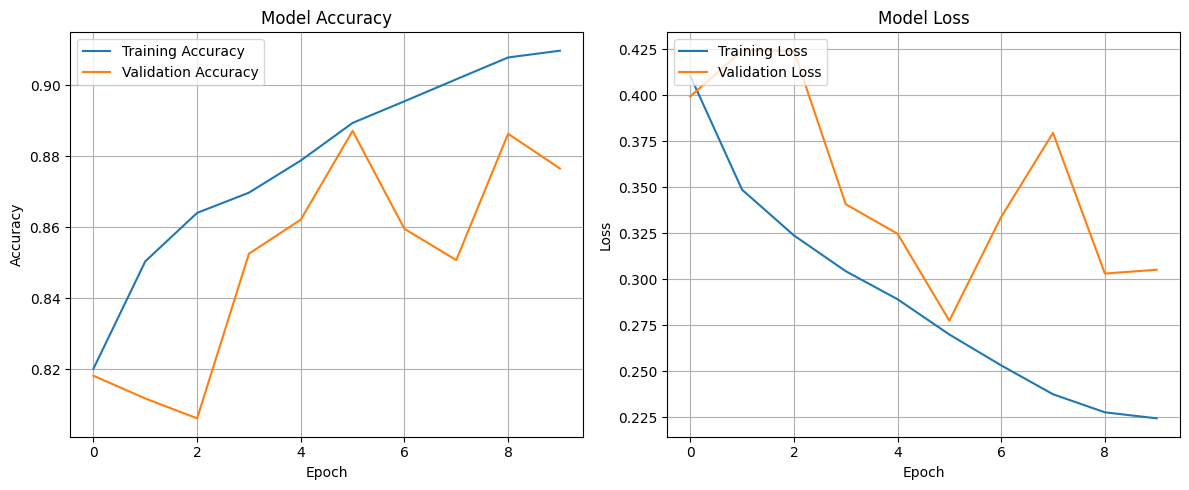

In [57]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid( )
plt.tight_layout()
plt.show()

In [73]:
model.predict(cat_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.00116013]], dtype=float32)

In [74]:
model.predict(dog_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.]], dtype=float32)

In [85]:
model.save('cat_dog_cnn_model.keras')
print("Model saved Successfully!")

Model saved Successfully!
